In [49]:
# Sam Brown
# Sam_brown@mines.edu
# July 11
# Goal: Explore more generalized models for predicting the time until next event

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Ideas
# Predicting the time bracket until the event. 
# Histogram of inter event time shows two large "humps" 
# Good splitting spot is 1100 minutes

df = pd.read_csv("/Users/sambrown04/Documents/SURF/Preproc_data/upd10-18.csv")

In [8]:
df.head()

,Unnamed: 0,tide_deriv,form_fac,time_since,slip_size_standardized,high_t_evt,start_time,sev_stds,pre-s_stds,tide_height,inter_form_Fac,A_diurn,A_semidiurn,disp_standardized,r2_standardized,slope_standardized
0,0,0.024640,3.782138,NaN,-1.931350,1,2010-01-01 15:25:00,-0.270159,-0.831226,108.956127,NaN,NaN,NaN,NaN,NaN,NaN
1,1,-0.232954,3.782138,512.50,-2.792976,0,2010-01-01 23:58:00,-0.668066,-0.739235,-126.423818,3.878220,112.390988,28.980043,-0.587568,-0.984690,-0.086702
2,2,-0.087155,3.126144,1037.75,-0.793920,1,2010-01-02 17:15:00,-0.180573,0.594509,94.249899,3.003587,100.522043,33.467327,1.170333,1.036672,0.760340
3,3,0.138536,2.571349,1382.75,-0.838199,1,2010-01-03 16:18:00,-0.209510,-0.773764,65.040870,2.356065,-88.364543,37.505133,2.147559,1.011620,1.531490
4,4,-0.484872,2.571349,445.00,-1.435594,0,2010-01-03 23:43:00,-0.204831,-0.806752,-57.608298,2.632244,76.161191,28.933946,-1.233834,-1.471552,-2.604936


(0.0, 2000.0)

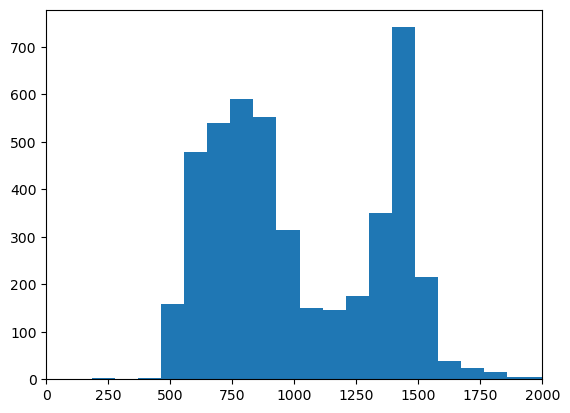

In [10]:
plt.hist(df['time_since'], bins = 600)
plt.xlim([0,2000])

In [11]:
# Encode just two for now, below 1100 minutes and above 1100 minutes, name 

In [53]:
df['time_bracket'] = (df['time_since'] > 1100).astype(int)


In [55]:
df = df[1:-1]

In [59]:
feat_cols = [
    'tide_deriv', 'form_fac', 'slip_size_standardized', 'sev_stds', 'pre-s_stds',
    'tide_height', 'inter_form_Fac', 'A_diurn', 'A_semidiurn',
    'r2_standardized', 'slope_standardized'
]

# drop rows where the target is missing
df = df[~df['time_bracket'].isna()]

# features target
X = df[feat_cols].to_numpy()
y = df['time_bracket'].to_numpy()

# split (stratified to keep class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# pipeline: impute scale then svm
svm_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),   # handle NaNs
    ("scale", StandardScaler()),
    ("svm", SVC(probability=True))                  # set class_weight="balanced" if needed (Not needed in this case confusion matrix looks healthy)
])

# hyperparams to try
svm_params = {
    "svm__kernel": ["rbf", "linear"],
    "svm__C": [0.1, 1, 10],
    "svm__gamma": ["scale", 0.1, 0.01]  # used for rbf; ignored for linear
}

# CV setup
cv_setup = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# grid search
svm_grid = GridSearchCV(
    estimator=svm_pipe,
    param_grid=svm_params,
    cv=cv_setup,
    scoring="accuracy",
    n_jobs=-1
)

# fit
svm_grid.fit(X_train, y_train)

# results
print("Best params:", svm_grid.best_params_)
test_preds = svm_grid.predict(X_test)
print("Accuracy:", accuracy_score(y_test, test_preds))
print("classification report:\n", classification_report(y_test, test_preds))
cm = confusion_matrix(y_test, test_preds)
print("Confusion matrix:\n", cm)

Best params: {'svm__C': 10, 'svm__gamma': 0.1, 'svm__kernel': 'rbf'}
Accuracy: 0.9704918032786886
classification report:
               precision    recall  f1-score   support

           0       0.97      0.98      0.98       554
           1       0.97      0.96      0.96       361

    accuracy                           0.97       915
   macro avg       0.97      0.97      0.97       915
weighted avg       0.97      0.97      0.97       915

Confusion matrix:
 [[543  11]
 [ 16 345]]


(4574, 17)